# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [3]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4-24231320/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [5]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
df["pct_change"] = (
    (df["attend_h1_2026"] - df["attend_h1_2025"])
    / df["attend_h1_2025"]
    * 100
)

display(df)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]
print(
    f"Largest fall: Triage {largest_fall['triage']} "
    f"({largest_fall['triage_name']}), {largest_fall['pct_change']:.1f}%"
)
print(
    f"Largest rise: Triage {largest_rise['triage']} "
    f"({largest_rise['triage_name']}), {largest_rise['pct_change']:.1f}%"
)

triage_4_5 = df.loc[df["triage"].isin([4, 5])]
attend_2025_4_5 = triage_4_5["attend_h1_2025"].sum()
attend_2026_4_5 = triage_4_5["attend_h1_2026"].sum()
combined_pct_change_4_5 = (
    (attend_2026_4_5 - attend_2025_4_5) / attend_2025_4_5 * 100
)
print(f"Triage 4+5 combined percentage change: {combined_pct_change_4_5:.1f}%")

,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall: Triage 5 (Non-urgent), -20.0%
Largest rise: Triage 1 (Critical), 5.0%
Triage 4+5 combined percentage change: -10.0%


In [7]:
# Task 1 note
task1_note = """
Triage 1–2 attendances both rose by about 5%, suggesting critical and emergency care was protected. 
Triage 4–5 attendances fell by 10.0% combined, consistent with lower-urgency attendances declining as described in the A&E claim.
"""
print(task1_note)




Triage 1–2 attendances both rose by about 5%, suggesting critical and emergency care was protected. 
Triage 4–5 attendances fell by 10.0% combined, consistent with lower-urgency attendances declining as described in the A&E claim.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


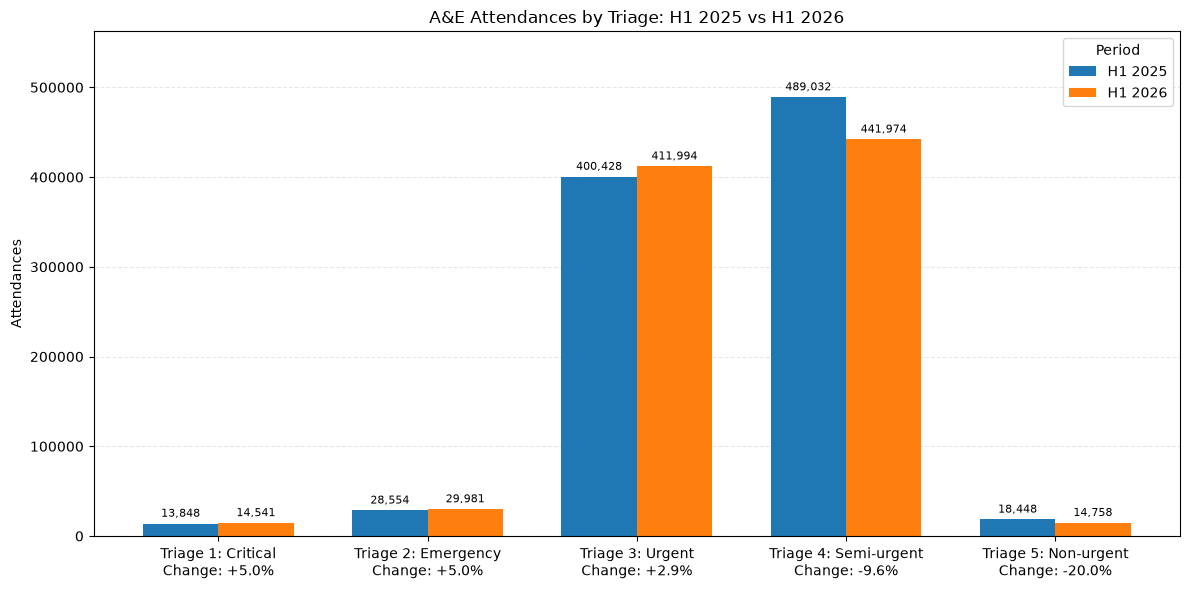

In [8]:
# Task 2
#
# Input: Task 1 df table with triage, triage_name, attendances, and pct_change
# Process: Compare H1 2025 and H1 2026 attendances in grouped bars;
#          label each bar with its attendance and each triage with its percentage change
# Output: Grouped bar chart with 5 triage groups and 10 bars

chart_df = df.sort_values("triage").copy()
positions = list(range(len(chart_df)))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))
bars_2025 = ax.bar(
    [position - bar_width / 2 for position in positions],
    chart_df["attend_h1_2025"],
    width=bar_width,
    label="H1 2025",
)
bars_2026 = ax.bar(
    [position + bar_width / 2 for position in positions],
    chart_df["attend_h1_2026"],
    width=bar_width,
    label="H1 2026",
)

for bars in (bars_2025, bars_2026):
    for bar in bars:
        attendance = int(bar.get_height())
        ax.annotate(
            f"{attendance:,}",
            (bar.get_x() + bar.get_width() / 2, attendance),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(positions)
ax.set_xticklabels(
    [
        f"Triage {row.triage}: {row.triage_name}\nChange: {row.pct_change:+.1f}%"
        for row in chart_df.itertuples()
    ]
)
ax.set_ylabel("Attendances")
ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.legend(title="Period")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, max(chart_df["attend_h1_2025"].max(), chart_df["attend_h1_2026"].max()) * 1.15)
fig.tight_layout()
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [10]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
Triage 4+5 combined attendances fell by 10.0%, 
while Triage 1–2 attendances rose by about 5%, 
consistent with lower-urgency attendances falling while critical/emergency demand was maintained.

3a GAP (1 point):
These before-and-after figures do not establish that fee reform caused the changes, 
and attendance and waiting-time measures alone do not show whether clinical outcomes improved.
"""

task3b = """
3b:
The evidence offers partial support for the claim: 
Triage 4+5 attendances fell by 10.0%, while Triage 1–2 rose by about 5%; 
the reported proportion of Triage III patients seen within 30 minutes also rose from 81.4% to 88.5%, 
and mean wait fell from 23 to 20 minutes. However, these before-and-after measures cannot show that fee reform caused the changes or establish whether patient outcomes improved. 
Overall, the trends are consistent with improvement, but they do not prove the full claim.
"""

print(task3a)
print("---")
print(task3b)


3a SUPPORT (1 point, cite a number):
Triage 4+5 combined attendances fell by 10.0%, 
while Triage 1–2 attendances rose by about 5%, 
consistent with lower-urgency attendances falling while critical/emergency demand was maintained.

3a GAP (1 point):
These before-and-after figures do not establish that fee reform caused the changes, 
and attendance and waiting-time measures alone do not show whether clinical outcomes improved.

---

3b:
The evidence offers partial support for the claim: 
Triage 4+5 attendances fell by 10.0%, while Triage 1–2 rose by about 5%; 
the reported proportion of Triage III patients seen within 30 minutes also rose from 81.4% to 88.5%, 
and mean wait fell from 23 to 20 minutes. However, these before-and-after measures cannot show that fee reform caused the changes or establish whether patient outcomes improved. 
Overall, the trends are consistent with improvement, but they do not prove the full claim.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
